In [1]:
import sys
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import torch

# Get the absolute path to the project root
project_root = os.path.dirname(os.path.dirname(os.getcwd()))

# Add correct paths
models_path = os.path.join(project_root, 'models')

# Append to sys.path\n",
sys.path.append(models_path)

from DKT.dkt_model import DKT


In [17]:
# Create one-hot vectors and obtain embeddings
def get_embedding(skill_id, model, num_skills):
    # Create one-hot vector as a tensor
    one_hot = torch.zeros(1, 1, num_skills)
    one_hot[0, 0, skill_id] = 1
    # Get the embedding for the one-hot vector
    embedding = model.embedding(one_hot) # Use skill_id-1 as index for embedding
    return embedding.squeeze(0).squeeze(0).detach().numpy()


In [6]:
# Load the configuration from the JSON file
with open('dkt_best_config.json', 'r') as f:
    best_config = json.load(f)

num_skills = best_config['model_params']['num_skills']
embedding_dim = best_config['model_params']['embed_dim']


model = DKT(**best_config['model_params'])
model.load_state_dict(torch.load('dkt_full_model.pth', map_location=torch.device('cpu')))
model.eval()  # Set the model to evaluation mode


C:\Users\Botond\AppData\Local\Temp\ipykernel_812\3314232336.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('dkt_full_model.pth', map_l

DKT(
  (embedding): CustomEmbedding(
    (linear): Linear(in_features=109, out_features=3, bias=False)
  )
  (rnn): LSTM(8, 200, batch_first=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (out): Linear(in_features=200, out_features=109, bias=True)
  (sigmoid): Sigmoid()
)

In [18]:
get_embedding(0, model, 109)

array([-0.5059649 ,  0.9830698 , -0.10103979], dtype=float32)

In [22]:
# Example parameters

# Initialize a list to store the embeddings
embedding_list = []

# Loop over all skill IDs to generate embeddings
for skill_id in range(num_skills):
    embedding = get_embedding(skill_id, model, num_skills)
    embedding_list.append(embedding)

# Convert the list of embeddings into a pandas DataFrame
df_embeddings = pd.DataFrame(embedding_list, columns=[f"embedding_{i+1}" for i in range(embedding_dim)], index=[f"skill_{i+1}" for i in range(num_skills)])

# Display the DataFrame
print(df_embeddings)

           embedding_1  embedding_2  embedding_3
skill_1      -0.505965     0.983070    -0.101040
skill_2      -0.387715     0.377652    -0.017617
skill_3       0.342388     0.345780    -0.449937
skill_4       0.226543     0.121772     0.365701
skill_5      -0.146033    -0.728054    -0.726663
...                ...          ...          ...
skill_105     0.520769    -0.237551     0.297774
skill_106     0.275004    -0.317959     0.477215
skill_107     0.277897     0.077687     0.200575
skill_108     0.225651     0.138668     0.355807
skill_109    -0.153251     0.578633     0.098066

[109 rows x 3 columns]


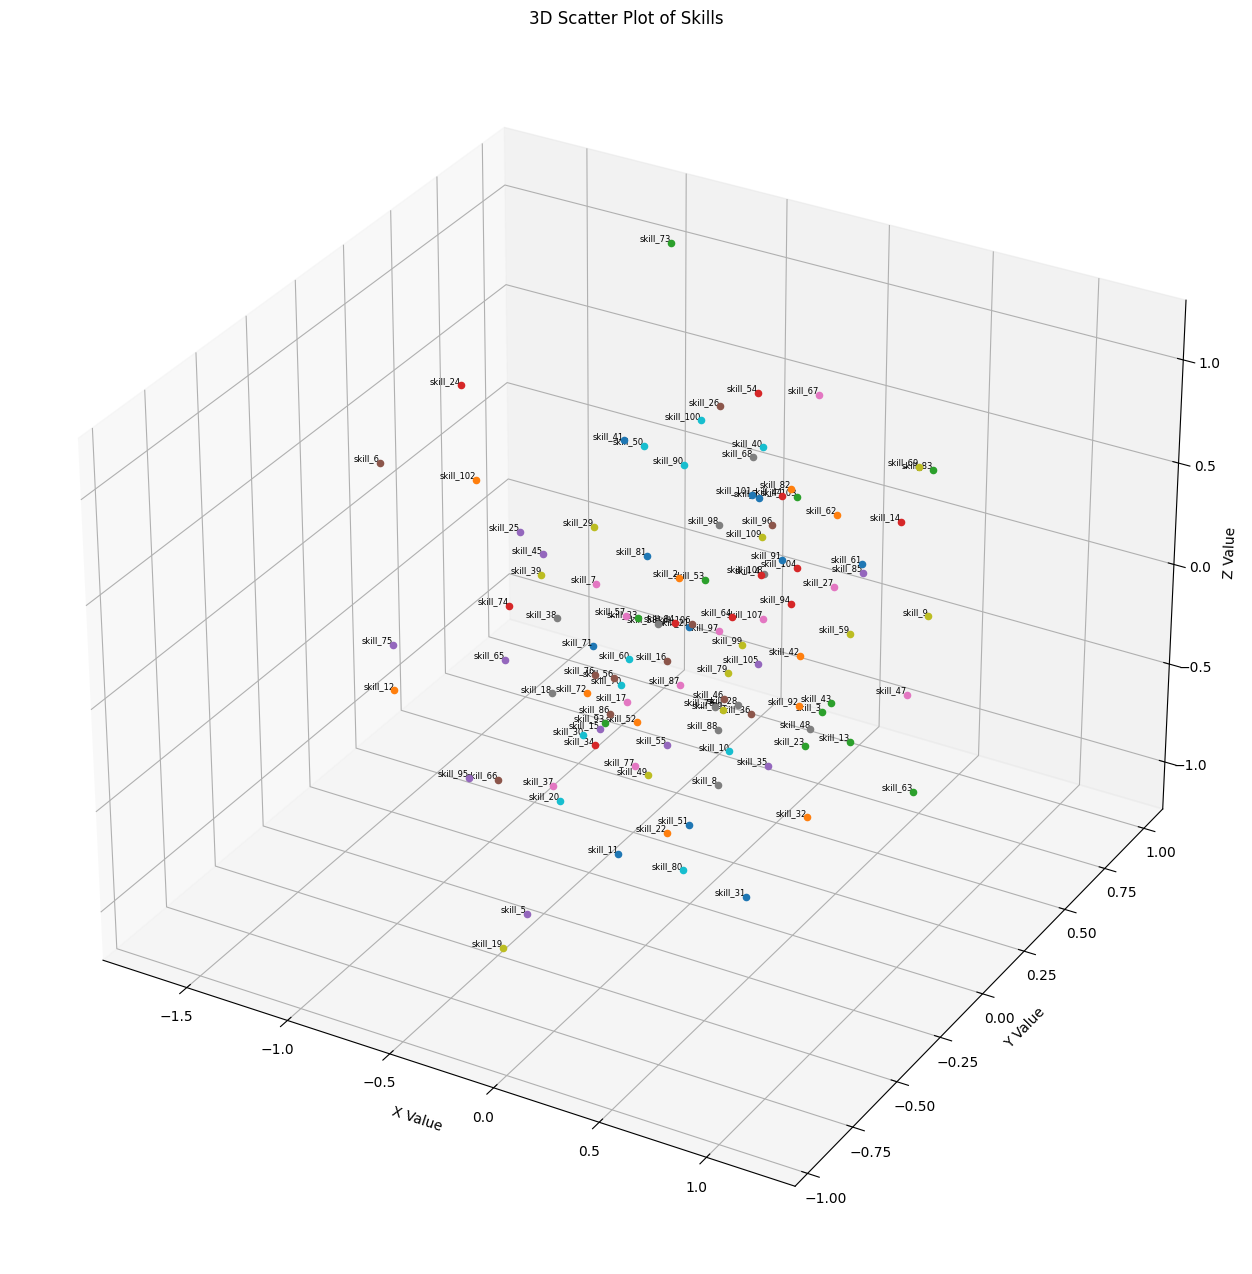

In [27]:
# Create a 3D scatter plot
fig = plt.figure(figsize=(16, 16))
ax = fig.add_subplot(111, projection='3d')

# Plot each point and annotate with 'skill_name'
for i, row in df_embeddings.iterrows():
    ax.scatter(row['embedding_1'], row['embedding_2'], row['embedding_3'])  # 3D coordinates
    ax.text(row['embedding_1'], row['embedding_2'], row['embedding_3'], i, fontsize=6, ha='right', va='bottom')

# Labels and title
ax.set_xlabel('X Value')
ax.set_ylabel('Y Value')
ax.set_zlabel('Z Value')
ax.set_title('3D Scatter Plot of Skills')

plt.show()


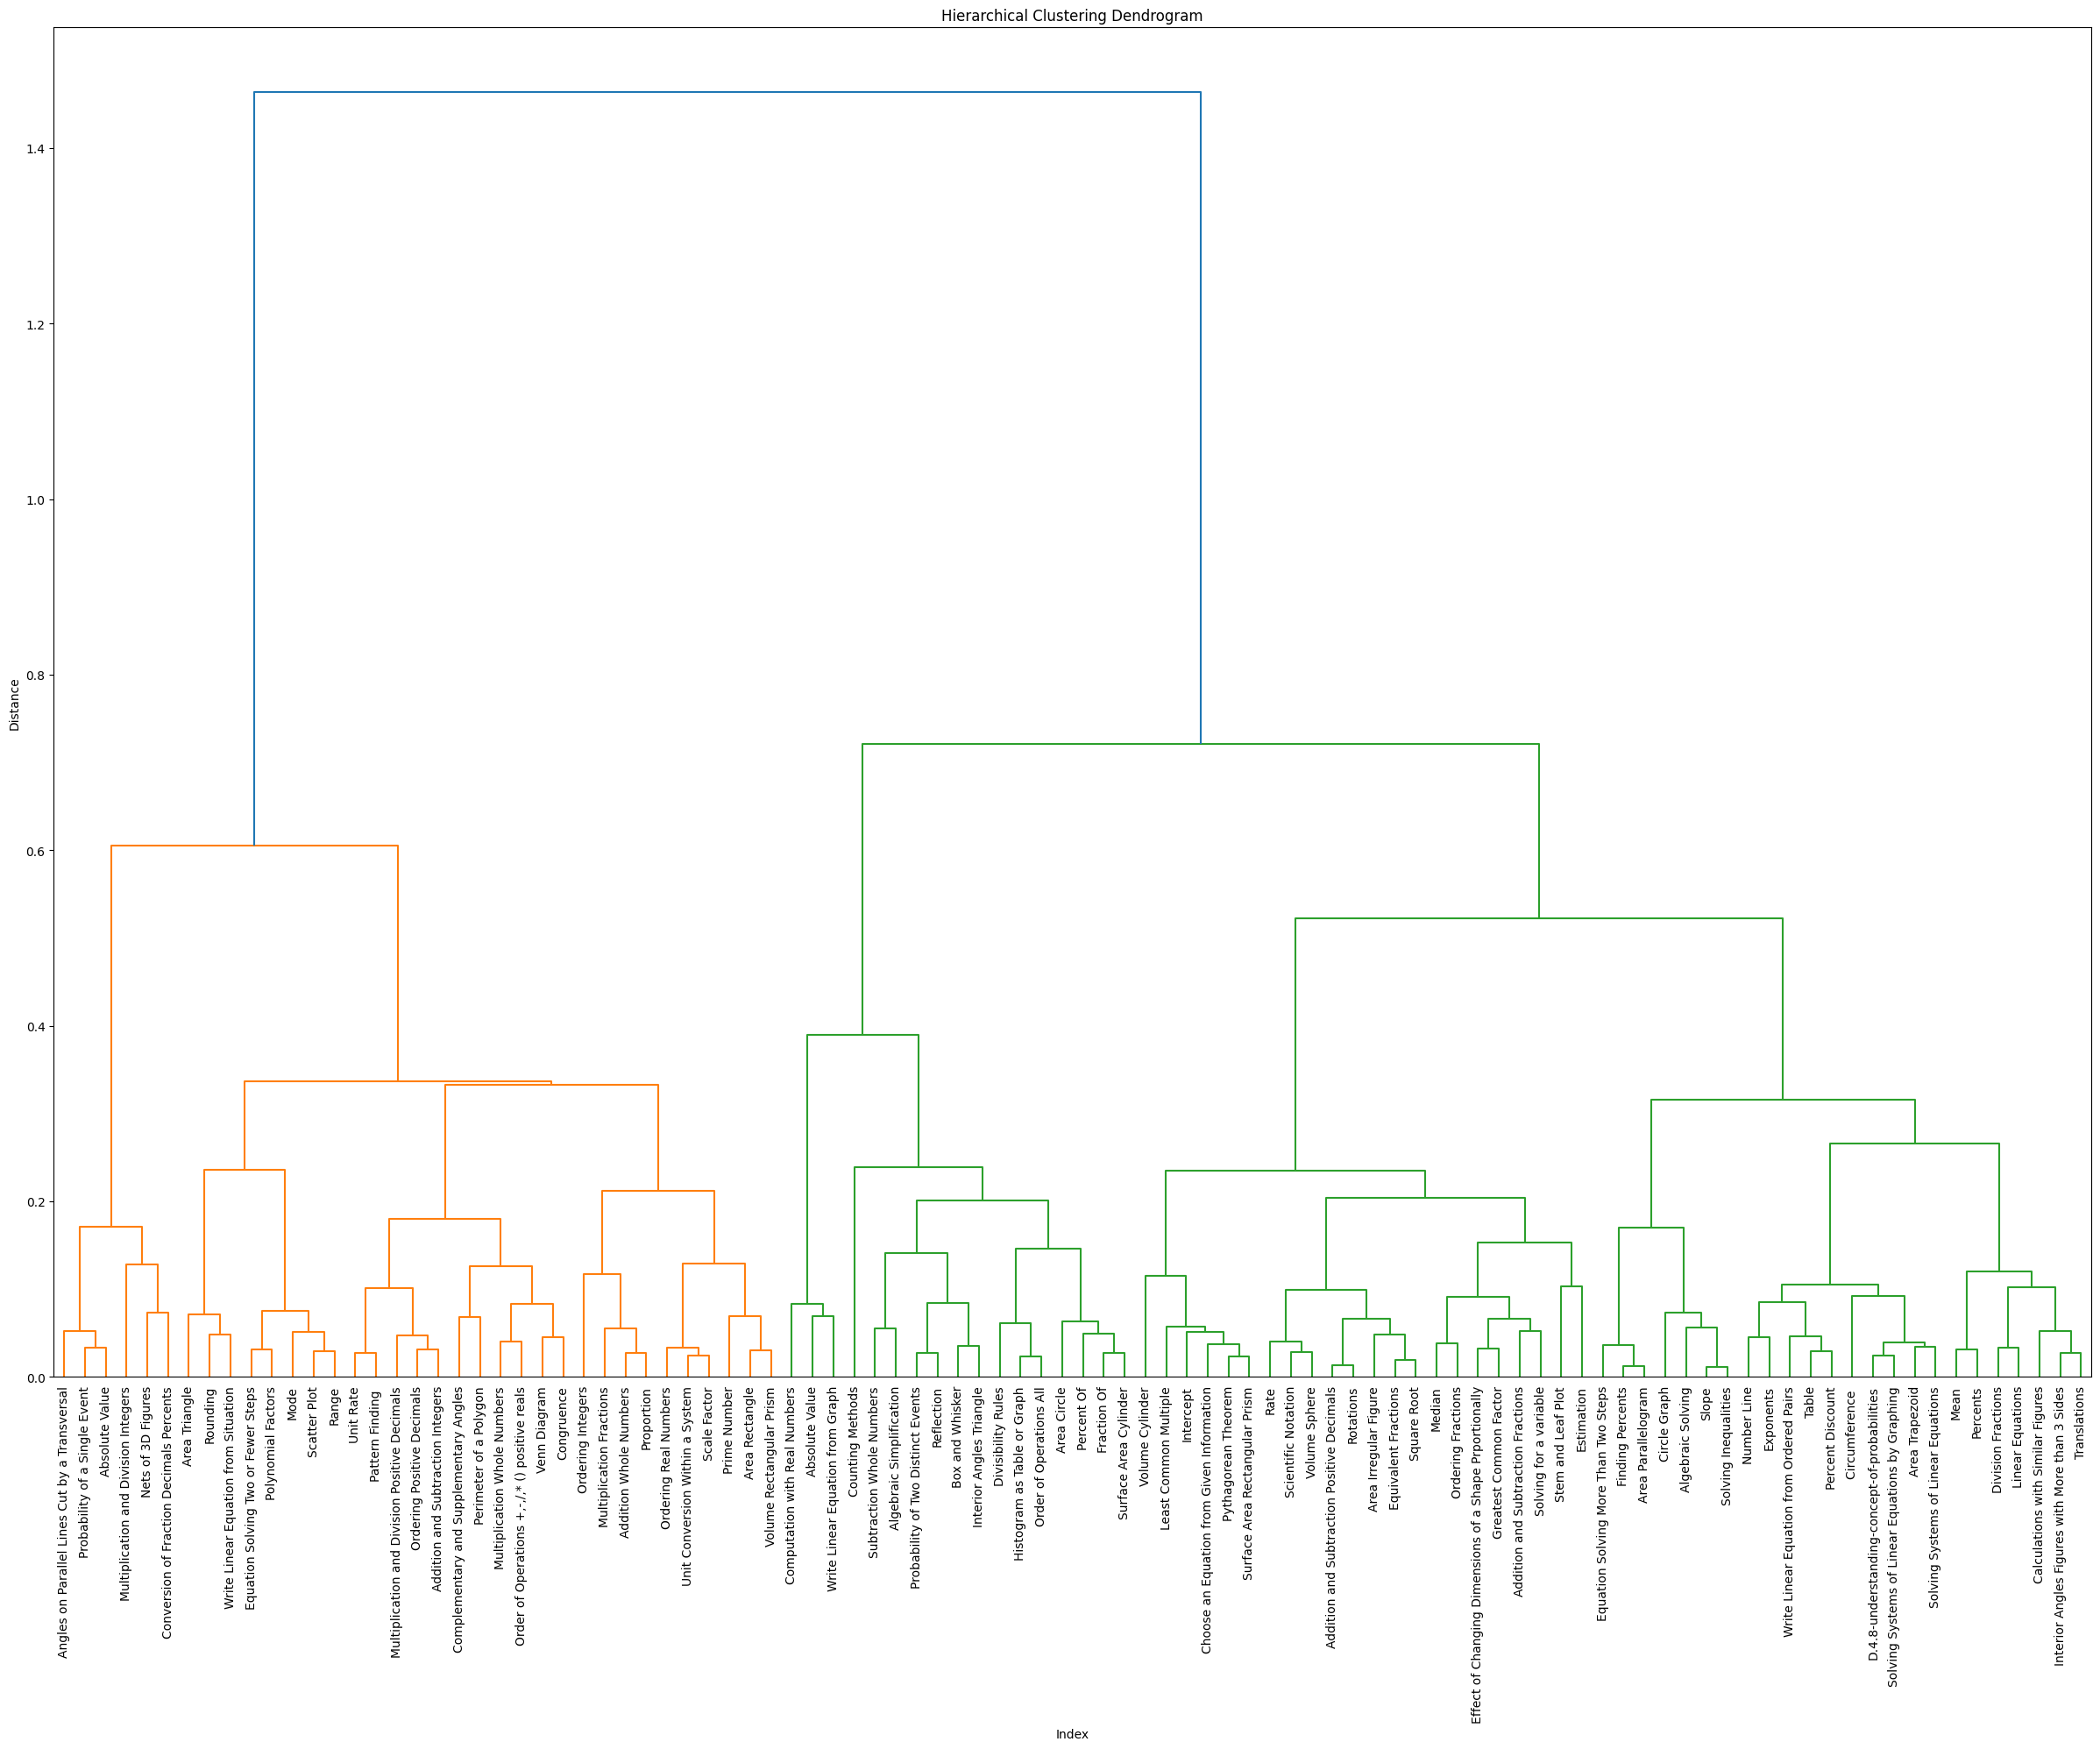

In [47]:
# Calculate the linkage matrix
linkage_matrix = sch.linkage(df_embeddings[['embed_1', 'embed_2', 'embed_3']], method='ward')

# Plot the dendrogram
plt.figure(figsize=(30, 20))
sch.dendrogram(linkage_matrix, labels=df_embeddings['skill_name'].values, leaf_rotation=90, leaf_font_size=10)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Index')
plt.ylabel('Distance')
plt.show()
